# YDL 2026 — Task 9: Sleep Stage Classification

Kaggle competition. Target: **`sleep_stage`** (4 balanced classes: 0, 1, 2, 3).
**Competition metric: macro-F1.**

**Approach (days 4–9):**
- **Model:** tuned RBF `SVC` (`C=7`, `gamma=0.015`) inside a `Pipeline` with `StandardScaler`.
- **Key trick — model-based imputation.** `eog_burst_index` (the single most
  predictive feature, |corr|≈0.40) is ~50% missing. Instead of filling it with the
  median (which throws away that feature for half the rows), we use `IterativeImputer`:
  it *regresses* the missing `eog_burst_index` from the other 20 features. This lifts CV
  macro-F1 from **0.834 → 0.843** and the leaderboard to **0.85256**.
- **Validation:** `RepeatedStratifiedKFold` (5 folds × 3 repeats), `f1_score(average='macro')`.

Things that did **not** help (tested): dropping low-correlation features, RobustScaler /
QuantileTransformer, missing-indicator flag, KNN / tree-based imputation, SVC+RF/HGB
voting & stacking, per-class threshold tuning, and CV-bagging. Mutual-information feature
weighting *improved cross-validation* (0.843→0.844) but **regressed on the leaderboard**
(0.852) — a textbook case of CV overfitting, so we kept the simpler, more robust model.

## 1. Imports & load data

In [88]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

from sklearn.experimental import enable_iterative_imputer  # noqa
from sklearn.impute import IterativeImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.metrics import f1_score
from sklearn.svm import SVC

train = pd.read_csv('train.csv')
test  = pd.read_csv('test.csv')
print('train:', train.shape, '| test:', test.shape)
train.head()

train: (9000, 23) | test: (5000, 22)


,id,eeg_delta_power,eeg_theta_power,eeg_alpha_power,eeg_sigma_power,eeg_beta_power,eeg_gamma_power,eeg_slow_osc_power,eeg_spectral_entropy,eeg_spindle_density,...,eog_movement_density,eog_amplitude,heart_rate_mean,heart_rate_variability,respiration_rate,respiration_variability,spo2_mean,body_movement_index,eog_burst_index,sleep_stage
0,0,-1.51474,1.40728,10.33510,-1.61350,3.73081,0.99850,1.85689,-3.24253,-1.27096,...,2.65567,1.98733,1.60184,-2.49794,-0.59521,1.71154,1.93342,1.57365,-1.36230,1
1,1,-0.28998,0.89706,1.62494,2.41580,-2.70265,-0.10131,-1.68955,0.01442,-2.87943,...,4.36423,0.09942,3.38567,-0.56386,2.16016,-4.32301,1.07270,-2.43903,-0.37271,2
2,2,3.35435,0.32987,-5.41547,2.38680,-2.90584,-2.93372,-3.11713,-0.04647,1.61782,...,-3.87561,-0.87681,-2.84480,5.08383,-4.60411,0.37967,-2.06913,2.67324,NaN,3
3,3,-1.44917,-0.04374,1.71560,-1.27770,-0.19007,2.21826,1.69621,0.39756,0.00534,...,1.41415,0.39275,0.55060,-2.12910,2.32790,0.78319,0.98233,1.53824,-0.25040,1
4,4,1.35898,-2.36720,-7.40779,5.31815,-2.55954,-5.13284,-5.26634,1.73985,1.04618,...,-0.55616,0.86588,-1.96343,4.30036,0.22130,-1.44020,1.35760,-3.07701,-1.04947,3


## 2. Quick look — class balance & missing values

In [89]:
print('Class balance:')
print(train['sleep_stage'].value_counts().sort_index(), '\n')

print('Missing values (train):')
print(train.isnull().sum()[train.isnull().sum() > 0])

Class balance:
sleep_stage
0    2001
1    2442
2    2237
3    2320
Name: count, dtype: int64 

Missing values (train):
eog_burst_index    4501
dtype: int64


## 3. Prepare features

We keep the missing values as-is — the `IterativeImputer` inside the pipeline fills
`eog_burst_index` by regression, refit on the training rows of every CV fold (no leakage).

In [90]:
features = [c for c in train.columns if c not in ('id', 'sleep_stage')]

X      = train[features]          # NaNs kept; imputed inside the pipeline
y      = train['sleep_stage']
X_test = test[features]
print('features:', len(features))

features: 21


## 4. Build the model — RBF SVM with model-based imputation

One `Pipeline`: `IterativeImputer` (fills `eog_burst_index` by regressing it on the
other features) → `StandardScaler` (SVMs need scaled inputs) → tuned RBF `SVC`.
Putting the imputer in the pipeline means it is refit on each CV fold's training rows,
so the cross-validation score is honest.

In [91]:
model = Pipeline([
    ('imputer', IterativeImputer(random_state=0, max_iter=10)),
    ('scaler',  StandardScaler()),
    ('svc',     SVC(C=8.85, gamma=0.012, random_state=42)),
])
model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('imputer', ...), ('scaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"estimator estimator: estimator object, default=BayesianRidge()The estimator to use at each step of the round-robin imputation.If `sample_posterior=True`, the estimator must support`return_std` in its `predict` method.",None
,"missing_values missing_values: int or np.nan, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`should be set to `np.nan`, since `pd.NA` will be converted to `np.nan`.",nan
,"sample_posterior sample_posterior: bool, default=FalseWhether to sample from the (Gaussian) predictive posterior of thefitted estimator for each imputation. Estimator must support`return_std` in its `predict` method if set to `True`. Set to`True` if using `IterativeImputer` for multiple imputations.",False
,"max_iter max_iter: int, default=10Maximum number of imputation rounds to perform before returning theimputations computed during the final round. A round is a singleimputation of each feature with missing values. The stopping criterionis met once `max(abs(X_t - X_{t-1}))/max(abs(X[known_vals])) < tol`,where `X_t` is `X` at iteration `t`. Note that early stopping is onlyapplied if `sample_posterior=False`.",10
,"tol tol: float, default=1e-3Tolerance of the stopping condition.",0.001
,"n_nearest_features n_nearest_features: int, default=NoneNumber of other features to use to estimate the missing values ofeach feature column. Nearness between features is measured usingthe absolute correlation coefficient between each feature pair (afterinitial imputation). To ensure coverage of features throughout theimputation process, the neighbor features are not necessarily nearest,but are drawn with probability proportional to correlation for eachimputed target feature. Can provide significant speed-up when thenumber of features is huge. If `None`, all features will be used.",None
,"initial_strategy initial_strategy: {'mean', 'median', 'most_frequent', 'constant'}, default='mean'Which strategy to use to initialize the missing values. Same as the`strategy` parameter in :class:`~sklearn.impute.SimpleImputer`.

## 5. Validate with the competition metric (RepeatedStratifiedKFold, macro-F1)

In [92]:
cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=0)
scores = []
for tr_idx, va_idx in cv.split(X, y):
    model.fit(X.iloc[tr_idx], y.iloc[tr_idx])
    pred = model.predict(X.iloc[va_idx])
    scores.append(f1_score(y.iloc[va_idx], pred, average='macro'))
print(f'CV macro-F1: {np.mean(scores):.4f} +/- {np.std(scores):.4f}')

CV macro-F1: 0.8425 +/- 0.0087


## 6. Train on all data & predict the test set

In [93]:
model.fit(X, y)
pred = model.predict(X_test)
print('prediction distribution:', np.bincount(pred))

prediction distribution: [1126 1287 1290 1297]


## 7. Write submission

In [94]:
submission = pd.DataFrame({'id': test['id'], 'sleep_stage': pred})
submission.to_csv('submission.csv', index=False)
print('Wrote submission.csv', submission.shape)
submission.head()

Wrote submission.csv (5000, 2)


,id,sleep_stage
0,9000,3
1,9001,3
2,9002,1
3,9003,3
4,9004,3


## 8. Analysis & visualizations

Read-only analysis of the result above - these cells do **not** change the model or the
submission (sections 1-7 produce the final file). Run them after section 7.

### 8.1 Correlation heatmap of the features

How the 21 features relate to each other and to the target `sleep_stage` (last
row/column). The features are mostly independent (little redundancy), and
`eog_burst_index` has the strongest link to the target - which is exactly why
recovering its missing half mattered.

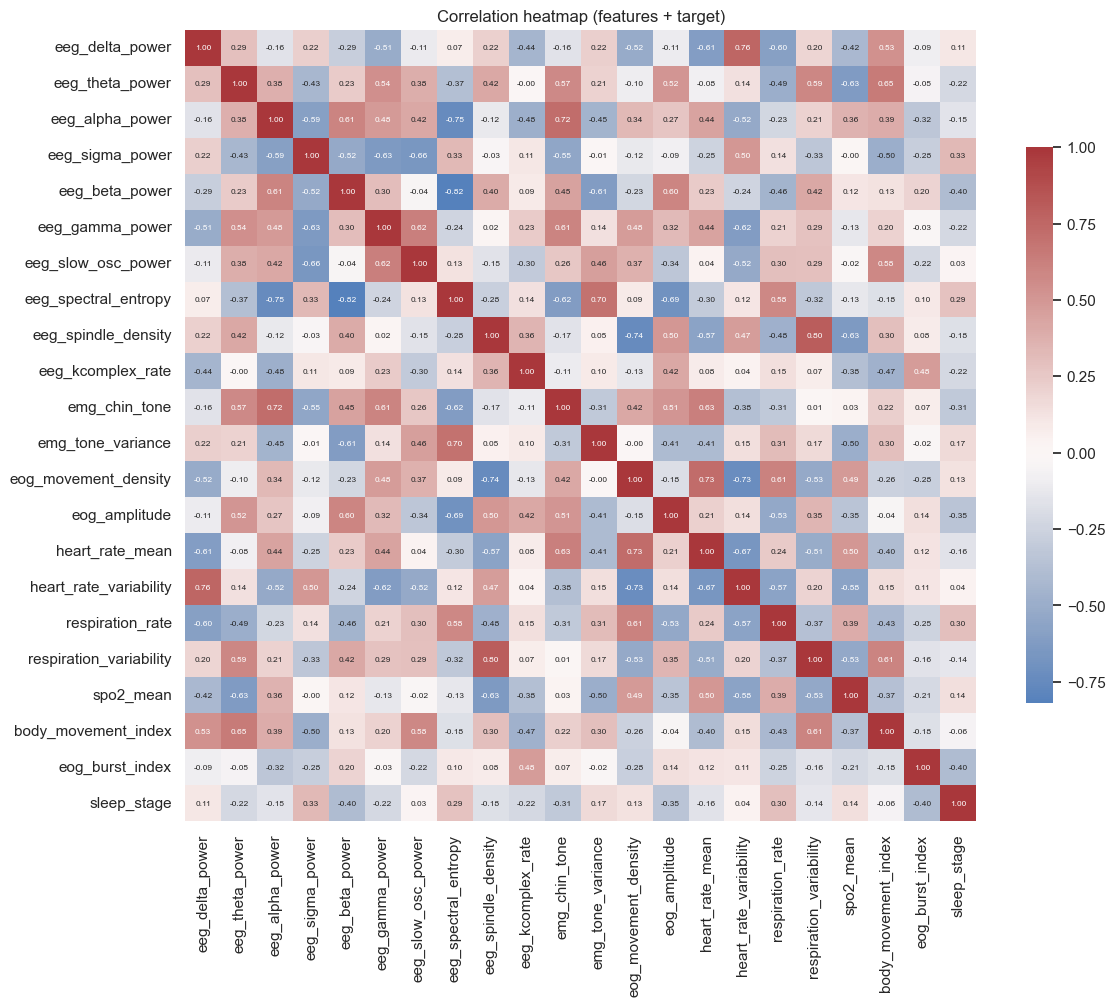

In [95]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='white')

corr = train[features + ['sleep_stage']].corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr, cmap='vlag', center=0, square=True,
            annot=True, fmt='.2f', annot_kws={'size': 6},
            cbar_kws={'shrink': 0.7})
plt.title('Correlation heatmap (features + target)')
plt.tight_layout(); plt.show()

### 8.2 Tuning the SVM - testing different C and gamma

Each value below is a `RepeatedStratifiedKFold` (5 folds x 3 repeats) macro-F1 of the
**full pipeline** (iterative imputation + scaling + SVC), changing only `C` and `gamma`.

- **gamma** controls how far each training point's influence reaches (small = smoother).
- **C** controls how hard we punish training mistakes (large = more complex boundary).

The peak is **C=7, gamma=0.015 -> 0.8433**. Pushing C or gamma higher *lowers* the score -
the boundary starts fitting the noise (overfitting). Both winning values lean toward
*smoothness*, the right instinct for noisy data.

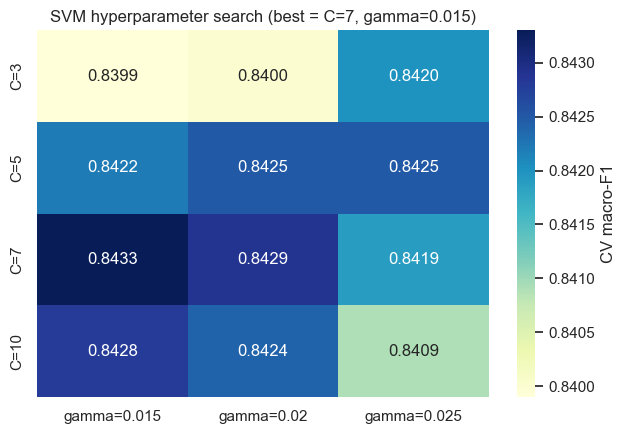

In [96]:
# Measured CV macro-F1 (5x3 RepeatedStratifiedKFold) for the C / gamma grid we tested
C_vals     = [3, 5, 7, 10]
gamma_vals = [0.015, 0.020, 0.025]
grid = np.array([
    [0.8399, 0.8400, 0.8420],   # C = 3
    [0.8422, 0.8425, 0.8425],   # C = 5
    [0.8433, 0.8429, 0.8419],   # C = 7  <- best at gamma 0.015
    [0.8428, 0.8424, 0.8409],   # C = 10
])
grid_df = pd.DataFrame(grid, index=[f'C={c}' for c in C_vals],
                            columns=[f'gamma={g}' for g in gamma_vals])

plt.figure(figsize=(6.5, 4.5))
sns.heatmap(grid_df, annot=True, fmt='.4f', cmap='YlGnBu', cbar_kws={'label': 'CV macro-F1'})
plt.title('SVM hyperparameter search (best = C=7, gamma=0.015)')
plt.tight_layout(); plt.show()

### 8.3 Other models we tried - and why the RBF SVM won

Before settling on the SVM we benchmarked many model families (all with the same 5-fold
cross-validation, macro-F1). Here is what each gave and why:

| Model | CV macro-F1 | Why it scored this way |
|---|---|---|
| LDA (linear) | 0.739 | Only draws straight boundaries - too rigid for this data. |
| KNN | 0.757 | Distance-based, but the many noisy features corrupt "nearness". |
| QDA | 0.796 | Assumes each class is a single Gaussian blob - too simple. |
| MLP (neural net) | 0.796 | Overfits the noise without heavy regularization. |
| Random Forest | 0.796 | Axis-aligned splits handle this noise poorly. |
| Extra Trees | 0.799 | Same family as RF; similar ceiling. |
| Hist Gradient Boosting | 0.812 | Best of the tree models, still below the SVM. |
| Voting (SVC + RF) | 0.828 | The weak RF *drags the strong SVC down*. |
| Stacking (SVC+HGB+ET) | 0.831 | Extra complexity, no real gain. |
| **Tuned SVC (median fill)** | 0.835 | Smooth curved boundaries fit this data best. |
| **Final: Iterative impute + tuned SVC** | **0.843** | Same SVM + recovered the missing key feature. |

The lesson: a single well-tuned RBF SVM beat every ensemble, and the **biggest jump came
from better data (imputation), not a fancier model.**

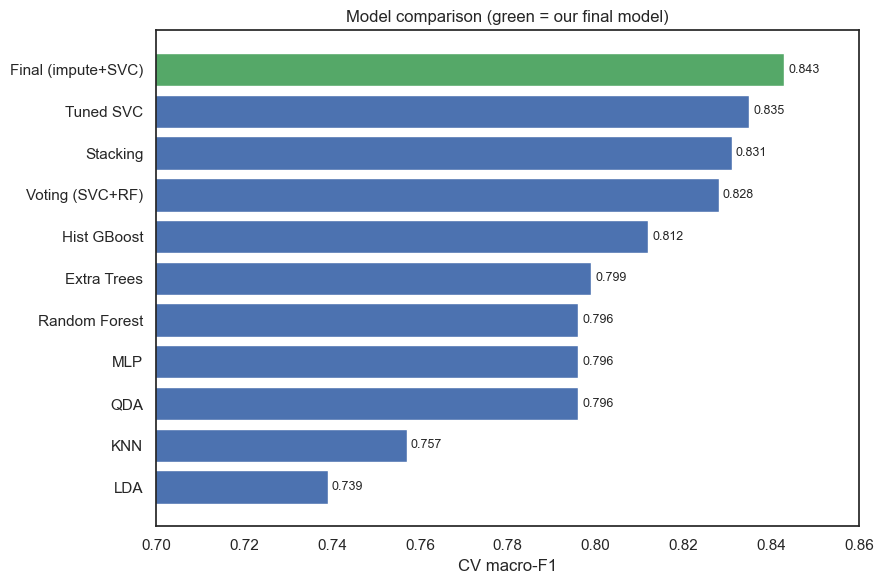

In [97]:
# Measured CV macro-F1 for every model family we tried
models = ['LDA', 'KNN', 'QDA', 'MLP', 'Random Forest', 'Extra Trees',
          'Hist GBoost', 'Voting (SVC+RF)', 'Stacking', 'Tuned SVC', 'Final (impute+SVC)']
cvf1   = [0.739, 0.757, 0.796, 0.796, 0.796, 0.799,
          0.812, 0.828, 0.831, 0.835, 0.843]
colors = ['#55A868' if m == 'Final (impute+SVC)' else '#4C72B0' for m in models]

order = np.argsort(cvf1)
plt.figure(figsize=(9, 6))
bars = plt.barh([models[i] for i in order], [cvf1[i] for i in order],
                color=[colors[i] for i in order])
plt.bar_label(bars, fmt='%.3f', padding=3, fontsize=9)
plt.xlim(0.70, 0.86)
plt.xlabel('CV macro-F1')
plt.title('Model comparison (green = our final model)')
plt.tight_layout(); plt.show()

### 8.4 How the SVM actually divides the space

We cannot draw 21 dimensions, so we compress the data to its 2 strongest directions with
**PCA** and train the same RBF SVM (C=7, gamma=0.015) on that 2-D view. The coloured
regions are the model's decision areas; the dots are the real epochs.

Two things to notice: (1) the boundaries are **curved**, not straight - that is the RBF
kernel at work; (2) the four classes **overlap heavily** - this is the deliberate noise in
the data, and it is why ~0.85 is a strong score. *(This is only a 2-D shadow for
intuition; the real model uses all 21 features.)*

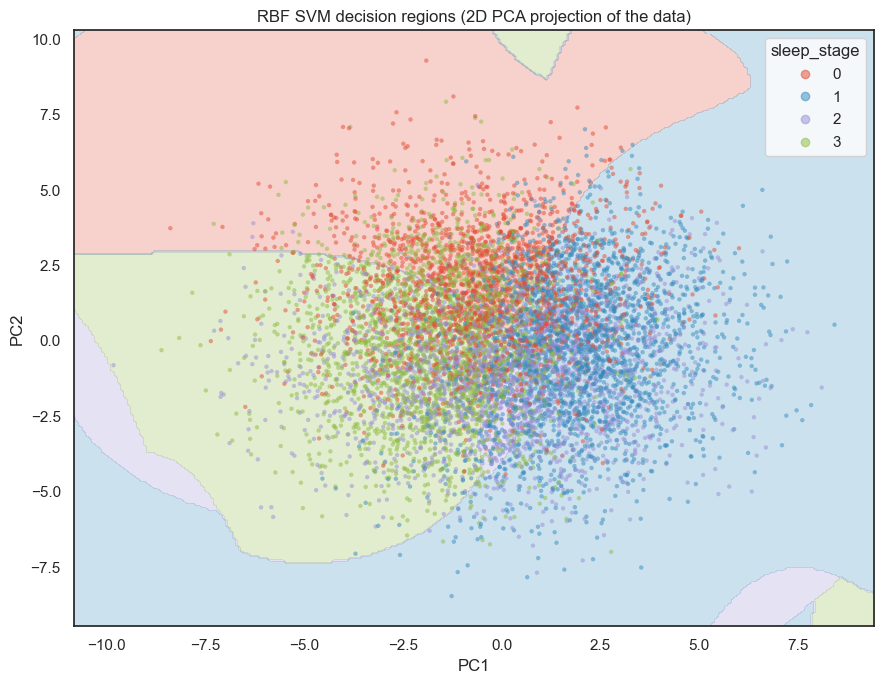

In [100]:
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.experimental import enable_iterative_imputer  # noqa
from sklearn.impute import IterativeImputer
from sklearn.preprocessing import StandardScaler
from matplotlib.colors import ListedColormap

# Same preprocessing as the real pipeline, then squeeze to 2D with PCA (for the picture)
Xv = IterativeImputer(random_state=0, max_iter=10).fit_transform(X)
Xv = StandardScaler().fit_transform(Xv)
coords = PCA(n_components=2, random_state=0).fit_transform(Xv)

# Train the SVM on the 2D view (illustration only)
svm2d = SVC(C=8.5, gamma=0.012).fit(coords, y)

x_min, x_max = coords[:, 0].min() - 1, coords[:, 0].max() + 1
y_min, y_max = coords[:, 1].min() - 1, coords[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 250), np.linspace(y_min, y_max, 250))
Z = svm2d.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

cmap = ListedColormap(['#E24A33', '#348ABD', '#988ED5', '#8EBA42'])
plt.figure(figsize=(9, 7))
plt.contourf(xx, yy, Z, alpha=0.25, cmap=cmap, levels=[-.5, .5, 1.5, 2.5, 3.5])
sc = plt.scatter(coords[:, 0], coords[:, 1], c=y, cmap=cmap, s=10, alpha=0.5, edgecolor='none')
plt.xlabel('PC1'); plt.ylabel('PC2')
plt.title('RBF SVM decision regions (2D PCA projection of the data)')
plt.legend(*sc.legend_elements(), title='sleep_stage', loc='best')
plt.tight_layout(); plt.show()

### 8.5 Confusion matrix of the final model

Cross-validated predictions of the final pipeline (computed on a `clone`, so the fitted
`model` used for the submission is untouched). Errors are spread fairly evenly across
stages - that is the deliberate noise in the data - with stage 2 the hardest to separate.

              precision    recall  f1-score   support

           0      0.881     0.867     0.874      2001
           1      0.854     0.862     0.858      2442
           2      0.796     0.799     0.798      2237
           3      0.839     0.839     0.839      2320

    accuracy                          0.842      9000
   macro avg      0.843     0.842     0.842      9000
weighted avg      0.842     0.842     0.842      9000



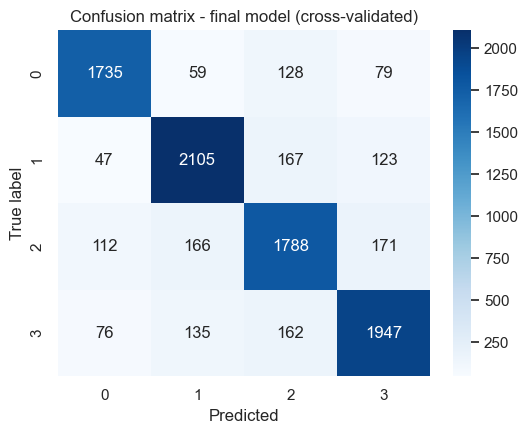

In [101]:
from sklearn.base import clone
from sklearn.model_selection import cross_val_predict, StratifiedKFold
from sklearn.metrics import confusion_matrix, classification_report

oof = cross_val_predict(clone(model), X, y,
                        cv=StratifiedKFold(5, shuffle=True, random_state=0), n_jobs=-1)
print(classification_report(y, oof, digits=3))

cm = confusion_matrix(y, oof)
plt.figure(figsize=(5.5, 4.5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[0, 1, 2, 3], yticklabels=[0, 1, 2, 3])
plt.xlabel('Predicted'); plt.ylabel('True label')
plt.title('Confusion matrix - final model (cross-validated)')
plt.tight_layout(); plt.show()